In [1]:
# ==============================
# Import Required Libraries
# ==============================

import warnings
warnings.filterwarnings("ignore")

# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Save Model
import joblib

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# ==============================
# Load Dataset
# ==============================

raw_df = pd.read_excel("../dataset/Telco_customer_churn.xlsx")

print("Dataset Loaded Successfully!\n")

print("Shape of Dataset:")
print(raw_df.shape)

Dataset Loaded Successfully!

Shape of Dataset:
(7043, 33)


In [3]:
raw_df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [4]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [5]:
raw_df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [6]:
duplicates = raw_df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 0


In [7]:
raw_df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [8]:
raw_df["Churn Label"].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

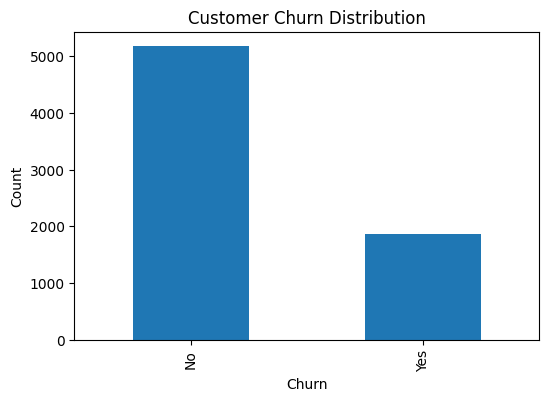

In [9]:
plt.figure(figsize=(6,4))

raw_df["Churn Label"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

In [10]:
# ==============================
# Create Working Copy
# ==============================

clean_df = raw_df.copy()

print("Working copy created successfully.")

Working copy created successfully.


In [11]:
print(clean_df.columns.tolist())

['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


In [12]:
clean_df.dtypes

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

In [13]:
clean_df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [14]:
blank_total = (clean_df["Total Charges"].astype(str).str.strip() == "").sum()

print("Blank values in Total Charges:", blank_total)

Blank values in Total Charges: 11


In [15]:
clean_df["Total Charges"] = pd.to_numeric(
    clean_df["Total Charges"],
    errors="coerce"
)

In [16]:
clean_df["Total Charges"].isnull().sum()

np.int64(11)

In [17]:
clean_df["Total Charges"] = clean_df["Total Charges"].fillna(
    clean_df["Total Charges"].median()
)

In [18]:
clean_df["Total Charges"].isnull().sum()

np.int64(0)

In [19]:
columns_to_drop = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Score",
    "Churn Reason",
    "Customer Status"
]

existing_columns = [col for col in columns_to_drop if col in clean_df.columns]

clean_df.drop(columns=existing_columns, inplace=True)

print("Remaining Columns:", clean_df.shape[1])

Remaining Columns: 22


In [20]:
clean_df.to_csv("clean_customer_churn.csv", index=False)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.


In [21]:
clean_df.shape

(7043, 22)

In [22]:
clean_df.columns.tolist()

['Gender',
 'Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Label',
 'Churn Value',
 'CLTV']

In [23]:
# ==============================
# Create Encoded Dataset
# ==============================

encoded_df = clean_df.copy()

print("Encoded dataframe created successfully.")

Encoded dataframe created successfully.


In [24]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

categorical_cols = encoded_df.select_dtypes(include="object").columns.tolist()

print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Churn Label']


In [25]:
for col in categorical_cols:
    le = LabelEncoder()

    encoded_df[col] = le.fit_transform(encoded_df[col].astype(str))

    encoders[col] = le

print("Encoding completed successfully.")

Encoding completed successfully.


In [26]:
encoded_df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,CLTV
0,1,0,0,0,2,1,0,0,2,2,...,0,0,0,1,3,53.85,108.15,1,1,3239
1,0,0,0,1,2,1,0,1,0,0,...,0,0,0,1,2,70.70,151.65,1,1,2701
2,0,0,0,1,8,1,2,1,0,0,...,2,2,0,1,2,99.65,820.50,1,1,5372
3,0,0,1,1,28,1,2,1,0,0,...,2,2,0,1,2,104.80,3046.05,1,1,5003
4,1,0,0,1,49,1,2,1,0,2,...,2,2,0,1,0,103.70,5036.30,1,1,5340


In [27]:
import joblib

joblib.dump(encoders, "encoders.pkl")

print("Encoders saved successfully.")

Encoders saved successfully.


In [28]:
encoders["Gender"].classes_

array(['Female', 'Male'], dtype=object)

In [29]:
encoders["Contract"].classes_

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [30]:
encoders["Payment Method"].classes_

array(['Bank transfer (automatic)', 'Credit card (automatic)',
       'Electronic check', 'Mailed check'], dtype=object)

In [31]:
# ==============================
# Features and Target
# ==============================

X = encoded_df.drop(columns=["Churn Label", "Churn Value", "CLTV"])

y = encoded_df["Churn Value"]

print("Number of Features:", X.shape[1])
print("Target Shape:", y.shape)

Number of Features: 19
Target Shape: (7043,)


In [32]:
feature_columns = X.columns.tolist()

joblib.dump(feature_columns, "feature_columns.pkl")

print(feature_columns)

['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges']


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data: (5634, 19)
Testing Data : (1409, 19)


In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully.")

Scaling completed successfully.


In [35]:
joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully.")

Scaler saved successfully.


In [36]:
# ==========================================
# Train Machine Learning Models
# ==========================================

models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=42)
}

results = []

trained_models = {}

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    prediction = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, prediction)

    results.append([name, accuracy])

    trained_models[name] = model

print("Training Completed Successfully!")

Training Completed Successfully!


In [37]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df.reset_index(drop=True, inplace=True)

results_df

,Model,Accuracy
0,Logistic Regression,0.802697
1,SVM,0.799858
2,Random Forest,0.794180
3,KNN,0.754436
4,Decision Tree,0.727466


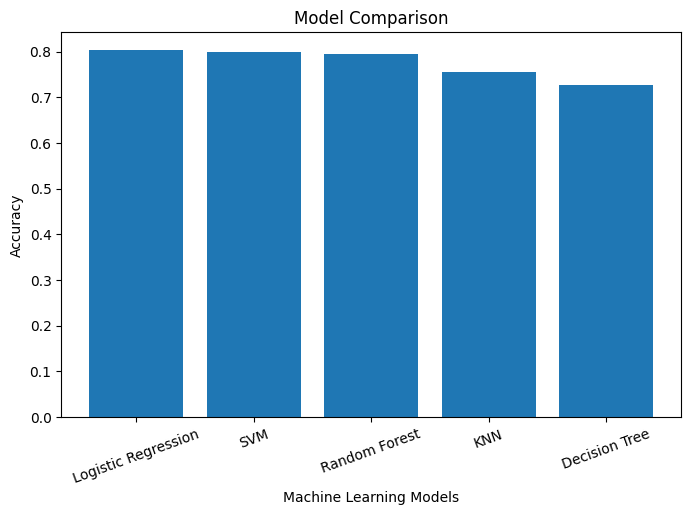

In [38]:
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["Accuracy"])

plt.title("Model Comparison")

plt.xlabel("Machine Learning Models")

plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

In [39]:
best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("Best Model :", best_model_name)

Best Model : Logistic Regression


In [40]:
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(best_model, "models/model.pkl")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(encoders, "models/encoders.pkl")
joblib.dump(feature_columns, "models/feature_columns.pkl")

print("All deployment files saved successfully!")

All deployment files saved successfully!


In [41]:
loaded_model = joblib.load("models/model.pkl")
loaded_scaler = joblib.load("models/scaler.pkl")

sample = X.iloc[[0]]

sample_scaled = loaded_scaler.transform(sample)

prediction = loaded_model.predict(sample_scaled)

probability = loaded_model.predict_proba(sample_scaled)

print("Prediction :", prediction[0])

print("Probability :", probability)

Prediction : 0
Probability : [[0.64224029 0.35775971]]


In [42]:
encoded_df.to_csv("encoded_customer_churn.csv", index=False)

print("Encoded dataset saved.")

Encoded dataset saved.


In [43]:
import joblib

# Load saved files
model = joblib.load("models/model.pkl")
scaler = joblib.load("models/scaler.pkl")

# Take one sample from test data
sample = X_test.iloc[[0]]

# Scale
sample_scaled = scaler.transform(sample)

# Predict
prediction = model.predict(sample_scaled)
probability = model.predict_proba(sample_scaled)

print("Prediction:", prediction[0])
print("Probability:", probability)

Prediction: 0
Probability: [[0.92617151 0.07382849]]


In [44]:
encoders = joblib.load("models/encoders.pkl")

print(encoders["Gender"].transform(["Male"]))
print(encoders["Gender"].transform(["Female"]))

print(encoders["Contract"].transform(["Month-to-month"]))

[1]
[0]
[0]
